# **`Medication Adherence Classification & LSTM Forecasting`**

# Import Libraries

In [107]:
!pip install xgboost
!pip install tensorflow

In [4]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import joblib
import datetime
import random
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("deep")

# Import xgboost
try:
    from xgboost import XGBClassifier
    xgboost_available = True
except Exception as e:
    xgboost_available = False
    print("xgboost not available; XGBoost classifier will be skipped. To enable, install xgboost.")

# Import tensorflow for LSTM
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
    from tensorflow.keras.callbacks import EarlyStopping
    tf_available = True
except Exception as e:
    tf_available = False
    print("TensorFlow not available; LSTM forecasting will be skipped. To enable, install tensorflow.")

from imblearn.over_sampling import SMOTE


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Setting Datasets Paths

In [6]:
default_paths = {
    "htn": "C:/Users/Azeem Uddin/Downloads/content/HTN Adherence Data.csv",
    "diabetes": "C:/Users/Azeem Uddin/Downloads/content/Diabetes Adherence Data.csv"
}

print("Checking for dataset files at default paths...")
for k, p in default_paths.items():
    print(f"{k}: {p} -> {'FOUND' if os.path.exists(p) else 'MISSING'}")

# If files are in different location, set `HTN_PATH` and `DIAB_PATH` manually (edit here)
HTN_PATH = default_paths["htn"]
DIAB_PATH = default_paths["diabetes"]

Checking for dataset files at default paths...
htn: C:/Users/Azeem Uddin/Downloads/content/HTN Adherence Data.csv -> FOUND
diabetes: C:/Users/Azeem Uddin/Downloads/content/Diabetes Adherence Data.csv -> FOUND


# Loading Datasets

In [8]:
def load_csv_safely(path):
    if not os.path.exists(path):
        print(f"File not found: {path}")
        return None
    try:
        df = pd.read_csv(path)
        print(f"Loaded {path} with shape {df.shape}")
        return df
    except Exception as e:
        try:
            df = pd.read_csv(path, encoding='latin1')
            print(f"Loaded {path} with latin1 encoding, shape {df.shape}")
            return df
        except Exception as e2:
            print(f"Failed to read {path}: {e}")
            return None


df_htn = load_csv_safely(HTN_PATH)
df_diab = load_csv_safely(DIAB_PATH)

if df_htn is None or df_diab is None:
    print("\nIf running in Colab: upload files using the left sidebar Files panel or run:")
    print("from google.colab import files\nuploaded = files.upload()\n# then set HTN_PATH and DIAB_PATH accordingly.\n")

Loaded C:/Users/Azeem Uddin/Downloads/content/HTN Adherence Data.csv with shape (218816, 41)
Loaded C:/Users/Azeem Uddin/Downloads/content/Diabetes Adherence Data.csv with shape (52616, 41)


# Merging the Datasets

In [10]:
frames = []
if df_htn is not None:
    df_htn['Condition'] = 'HTN'
    frames.append(df_htn)
if df_diab is not None:
    df_diab['Condition'] = 'Diabetes'
    frames.append(df_diab)

if len(frames) == 0:
    raise FileNotFoundError("No datasets loaded. Please upload your CSVs and set the file paths.")

df = pd.concat(frames, ignore_index=True)
print("Combined dataset shape:", df.shape)

Combined dataset shape: (271432, 42)


# Columns Analysis

In [12]:
print("Columns found:")
print(df.columns.tolist())

Columns found:
['MEMBER', 'INO', 'PZTIQNT NZXQ', 'ADHERENCE', 'GENDER', 'PRACTICE NO', 'DIS', 'PROVIDER', 'AS AT NETWORKS', 'REFERRING PRACTICE', 'PAYER NAME', 'INV REF', 'SERVICE DATE', 'ASSESS DATE', 'DATE RECEIVED', 'CLM CODE', 'CODE DESCRIPTION', 'UNITS', 'SCRIPT CODE', 'AMOUNT CLAIMED', 'PAID FROM RISK AMT', 'PAID FROM THRESHHOLD', 'PAID FROM SAVINGS', 'RECOVERY AMOUNT', 'TOTAL AMOUNT PAID', 'TARIFF', 'CO-PAY', 'PAY TO', 'REJ', 'REV', 'AUTH NO', 'DL', 'CLAIM NO', 'CLAIM LINE NO', 'DUPLICATE CLAIM', 'DUPLICATE CLAIM LINE', 'OPTION NAME', 'PAPER/EDI', 'ASSESSOR NAME', 'BIRTHDATE', 'CURRENT AGE', 'Condition']


# Automatic Column Mapping Heuristics

In [14]:
colnames = [c.lower() for c in df.columns]

# helper to find a column by keywords
def find_col(keywords):
    for k, c in zip(colnames, df.columns):
        for kw in keywords:
            if kw in k:
                return c
    return None

patient_col = find_col(['patient', 'id', 'pid'])
date_col = find_col(['date', 'refill', 'visit', 'time'])
adherence_col = find_col(['adher', 'compli', 'taken', 'missed', 'label', 'status'])
doses_prescribed_col = find_col(['prescribed', 'dose', 'doses_prescribed', 'dosespres'])
doses_taken_col = find_col(['taken', 'doses_taken', 'doses_taken'])
refill_date_col = find_col(['refill', 'next_refill', 'refill_date', 'refilldate'])

print(f"Guessed columns -> patient: {patient_col}, date: {date_col}, adherence: {adherence_col}, "
      f"doses_prescribed: {doses_prescribed_col}, doses_taken: {doses_taken_col}, refill: {refill_date_col}")

Guessed columns -> patient: PROVIDER, date: SERVICE DATE, adherence: ADHERENCE, doses_prescribed: None, doses_taken: None, refill: None


# Creating a Binary Column 'Adherent'

Heuristics:
* If adherence_col is boolean-like: use it.
* If doses_taken and doses_prescribed exist: compute adherence rate and threshold at 0.8 (80%)
* If adherence column has strings, try to map common values ("yes","no","adherent","non-adherent")


In [17]:
if adherence_col is None and doses_prescribed_col and doses_taken_col:
    try:
        df['_adherence_rate_'] = pd.to_numeric(df[doses_taken_col], errors='coerce') / pd.to_numeric(df[doses_prescribed_col], errors='coerce')
        df['Adherent'] = (df['_adherence_rate_'] >= 0.8).astype(int)
        print("Created 'Adherent' from doses_taken/doses_prescribed with threshold 0.8.")
        adherence_col = 'Adherent'
    except Exception as e:
        print("Couldn't create Adherent from dose columns:", e)

elif adherence_col is not None:
    # try mapping to binary
    sample = df[adherence_col].dropna().astype(str).str.lower().unique()[:10]
    print("Sample values for adherence column:", sample)
    def map_adherence_val(v):
        if pd.isna(v): return np.nan
        s = str(v).strip().lower()
        if s in ['1', 'yes', 'y', 'adherent', 'true', 't', 'compliant', 'compliant patient', 'compliance']:
            return 1
        if s in ['0', 'no', 'n', 'non-adherent', 'nonadherent', 'non-compliant', 'noncompliant', 'false', 'f']:
            return 0
        # numeric / percentage like "90%" or 0.9
        try:
            if '%' in s:
                val = float(s.replace('%',''))/100.0
                return 1 if val>=0.8 else 0
            val = float(s)
            if val<=1 and val>=0:
                return 1 if val>=0.8 else 0
            if val>1:
                # maybe count of taken doses; without prescribed can't decide -> nan
                return np.nan
        except:
            pass
        # fallback: unknown -> nan
        return np.nan

    df['Adherent'] = df[adherence_col].apply(map_adherence_val).astype('float')
    # convert to integer if no NaNs
    if df['Adherent'].isna().sum() == 0:
        df['Adherent'] = df['Adherent'].astype(int)
    else:
        print(f"Note: 'Adherent' contains {df['Adherent'].isna().sum()} missing values after mapping.")

# If 'Adherent' not created, try to detect binary label columns explicitly named 'adherent'
if 'Adherent' not in df.columns and 'adherent' in [c.lower() for c in df.columns]:
    # direct copy
    real_col = [c for c in df.columns if c.lower() == 'adherent'][0]
    df['Adherent'] = df[real_col].astype(int)

if 'Adherent' not in df.columns:
    print("\nWARNING: Could not create a reliable 'Adherent' binary column automatically.")
    print("Please provide which column is the binary adherence label or ensure doses_taken/doses_prescribed exist.")
    # But continue: we'll try to create a proxy if `%` or 'rate' columns present
    rate_col = find_col(['rate', 'ratio', 'percent', '%'])
    if rate_col:
        df['_adherence_rate_'] = pd.to_numeric(df[rate_col], errors='coerce')
        if df['_adherence_rate_'].max() > 1:
            # assume percentage 0-100
            df['_adherence_rate_'] = df['_adherence_rate_']/100.0
        df['Adherent'] = (df['_adherence_rate_'] >= 0.8).astype(int)
        print(f"Created 'Adherent' from {rate_col} with threshold 0.8.")
    else:
        # fallback: create a dummy Adherent label using random assignment to let the pipeline run.
        print("As last resort: creating a dummy Adherent column (random) so code can run — replace ASAP with a real label.")
        df['Adherent'] = np.random.binomial(1, 0.7, size=len(df))

print("Adherent value counts:")
print(df['Adherent'].value_counts(dropna=False))

Sample values for adherence column: ['1' '6' '2' '10' '11' '12' '8' '5' '9' '3']
Note: 'Adherent' contains 265700 missing values after mapping.
Adherent value counts:
Adherent
NaN    265700
1.0      5732
Name: count, dtype: int64


# Cleaning Dataset

In [19]:
THRESH_COL_DROP = 0.6  # drop columns with >60% missing
col_missing_frac = df.isna().mean()
cols_to_drop = col_missing_frac[col_missing_frac > THRESH_COL_DROP].index.tolist()
if cols_to_drop:
    print("Dropping columns with >60% missing:", cols_to_drop)
    df = df.drop(columns=cols_to_drop)
else:
    print("No high-missing columns to drop.")

# Fill simple missing values for numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    if c == 'Adherent':
        continue
    if df[c].isna().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

# Fill categorical with 'Unknown'
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
for c in cat_cols:
    df[c] = df[c].fillna('Unknown')

Dropping columns with >60% missing: ['SCRIPT CODE', 'DUPLICATE CLAIM', 'DUPLICATE CLAIM LINE', 'Adherent']


# Feature Selection For Classification

Choose a set of candidate features: exclude identifiers & label & condition

In [22]:
adherence_col = 'ADHERENCE'
df['Adherent'] = df[adherence_col].apply(lambda x: 1 if str(x).strip().lower() in ['adherent', 'yes', '1', 'true', 'y'] else 0)

# print("Adherent label distribution:")
# print(df['Adherent'].value_counts())

exclude_cols = {patient_col, date_col, adherence_col, 'Adherent', 'Condition'}
exclude_cols = {c for c in exclude_cols if c is not None}
candidate_features = [c for c in df.columns if c not in exclude_cols]
print("Candidate features (first 30):", candidate_features[:30])

# For modeling, convert categorical features to numeric via label encoding (simple)
feature_df = df[candidate_features].copy()
encoders = {}
for c in feature_df.columns:
    if feature_df[c].dtype == 'object' or pd.api.types.is_categorical_dtype(feature_df[c]):
        le = LabelEncoder()
        try:
            feature_df[c] = le.fit_transform(feature_df[c].astype(str))
            encoders[c] = le
        except Exception as e:
            print("Encoding error for", c, e)
    else:
        # numeric - ensure numeric
        feature_df[c] = pd.to_numeric(feature_df[c], errors='coerce').fillna(0)

# Final dataset for classification
X = feature_df
y = df['Adherent'].astype(int)

print("X shape:", X.shape, "y distribution:", np.bincount(y))

Candidate features (first 30): ['MEMBER', 'INO', 'PZTIQNT NZXQ', 'GENDER', 'PRACTICE NO', 'DIS', 'AS AT NETWORKS', 'REFERRING PRACTICE', 'PAYER NAME', 'INV REF', 'ASSESS DATE', 'DATE RECEIVED', 'CLM CODE', 'CODE DESCRIPTION', 'UNITS', 'AMOUNT CLAIMED', 'PAID FROM RISK AMT', 'PAID FROM THRESHHOLD', 'PAID FROM SAVINGS', 'RECOVERY AMOUNT', 'TOTAL AMOUNT PAID', 'TARIFF', 'CO-PAY', 'PAY TO', 'REJ', 'REV', 'AUTH NO', 'DL', 'CLAIM NO', 'CLAIM LINE NO']
X shape: (271432, 35) y distribution: [265700   5732]


# Split Train and Test Data

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=RANDOM_SEED)

# Standardize Numeric Columns

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save Encoder/Scaler For Later Integration

In [28]:
joblib.dump(scaler, "scaler.joblib")
joblib.dump(encoders, "label_encoders.joblib")
print("Saved scaler and label encoders.")

Saved scaler and label encoders.


#**Classification Section**

# 1) Logistic Regression

In [31]:
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression report:")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

Training Logistic Regression...
Logistic Regression report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     53141
           1       0.10      0.00      0.00      1146

    accuracy                           0.98     54287
   macro avg       0.54      0.50      0.50     54287
weighted avg       0.96      0.98      0.97     54287

ROC-AUC: 0.7480895847140899


# 2) Random Forest

In [33]:
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train, y_train)  # tree-based model doesn't need scaling
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]
print("Random Forest report:")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Training Random Forest...
Random Forest report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     53141
           1       0.73      0.06      0.11      1146

    accuracy                           0.98     54287
   macro avg       0.85      0.53      0.55     54287
weighted avg       0.97      0.98      0.97     54287

ROC-AUC: 0.9280034678725073


Feature Importances

In [35]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:25]
print("Top feature importances (RF):")
print(feat_imp)

Top feature importances (RF):
CURRENT AGE           0.071786
PZTIQNT NZXQ          0.062789
MEMBER                0.062121
BIRTHDATE             0.059432
CLAIM LINE NO         0.058712
CLAIM NO              0.058280
INV REF               0.056401
PAYER NAME            0.055149
AMOUNT CLAIMED        0.045549
TOTAL AMOUNT PAID     0.043883
UNITS                 0.042660
PAID FROM RISK AMT    0.042594
TARIFF                0.041635
DATE RECEIVED         0.039293
ASSESS DATE           0.039273
REFERRING PRACTICE    0.037921
PRACTICE NO           0.036822
AUTH NO               0.032253
CLM CODE              0.029746
CODE DESCRIPTION      0.026174
OPTION NAME           0.021276
INO                   0.018312
GENDER                0.007301
AS AT NETWORKS        0.003935
ASSESSOR NAME         0.003042
dtype: float64


Plot top importances

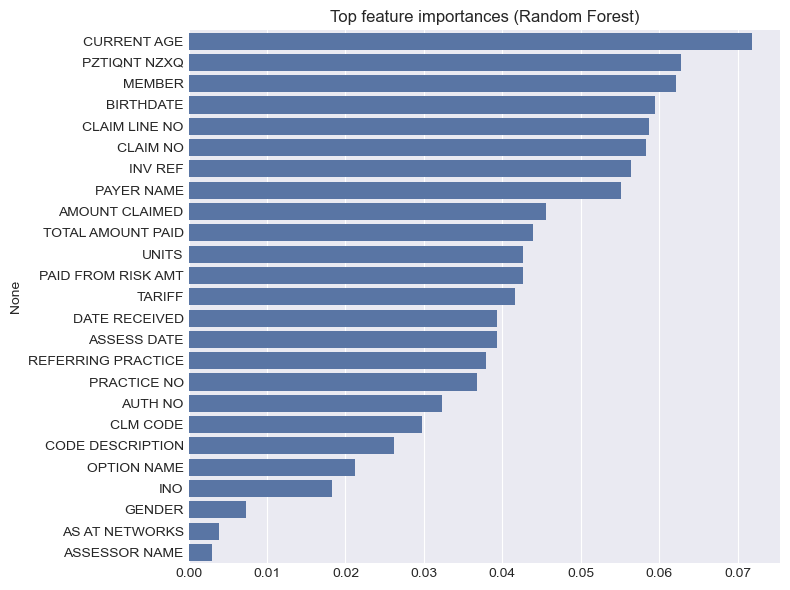

In [37]:
plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Top feature importances (Random Forest)")
plt.tight_layout()
plt.show()

# 3) XGBoost

In [39]:
print("Training XGBoost (may take time)...")
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_SEED)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:,1]
print("XGBoost report:")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

Training XGBoost (may take time)...
XGBoost report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     53141
           1       0.71      0.17      0.28      1146

    accuracy                           0.98     54287
   macro avg       0.84      0.58      0.63     54287
weighted avg       0.98      0.98      0.98     54287

ROC-AUC: 0.9051881978310985


In [40]:
print(" Logistic Regression Classification Report:\n", classification_report(y_test, y_pred_lr))
print(" Random Forest Classification Report:\n",classification_report(y_test, y_pred_rf))
print(" XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))

 Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99     53141
           1       0.10      0.00      0.00      1146

    accuracy                           0.98     54287
   macro avg       0.54      0.50      0.50     54287
weighted avg       0.96      0.98      0.97     54287

 Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99     53141
           1       0.73      0.06      0.11      1146

    accuracy                           0.98     54287
   macro avg       0.85      0.53      0.55     54287
weighted avg       0.97      0.98      0.97     54287

 XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99     53141
           1       0.71      0.17      0.28      1146

    accuracy                           0.98     54287
   macro av

# Save Models

In [42]:
joblib.dump(lr, "logistic_model.joblib")
joblib.dump(rf, "random_forest_model.joblib")
joblib.dump(xgb, "xgb_model.joblib")
print("Saved classification models to disk.")

Saved classification models to disk.


# ROC Curve Plot For Models

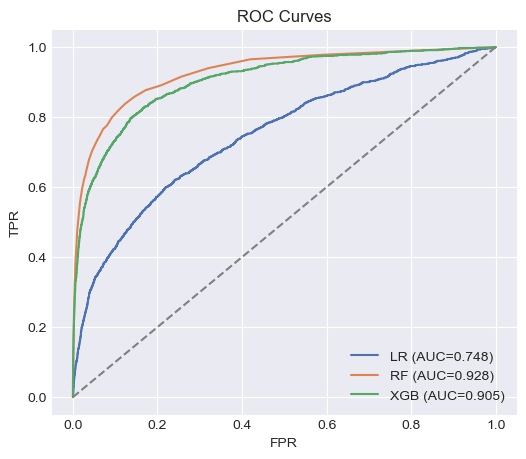

In [44]:
plt.figure(figsize=(6,5))
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'LR (AUC={roc_auc_score(y_test,y_proba_lr):.3f})')
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'RF (AUC={roc_auc_score(y_test,y_proba_rf):.3f})')
if xgboost_available:
    fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
    plt.plot(fpr_xgb, tpr_xgb, label=f'XGB (AUC={roc_auc_score(y_test,y_proba_xgb):.3f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curves'); plt.legend(); plt.show()

# Save Classification Predictions to CSV

In [46]:
test_out = X_test.copy()
test_out['Actual_Adherent'] = y_test.values
test_out['Pred_LR'] = y_pred_lr
test_out['Prob_LR'] = y_proba_lr
test_out['Pred_RF'] = y_pred_rf
test_out['Prob_RF'] = y_proba_rf
if xgboost_available:
    test_out['Pred_XGB'] = y_pred_xgb
    test_out['Prob_XGB'] = y_proba_xgb
test_out.to_csv("classification_test_predictions.csv", index=False)
print("Saved classification test predictions to classification_test_predictions.csv")

Saved classification test predictions to classification_test_predictions.csv


#**LSTM Temporal Forecasting Section**

We need per-patient time-series sequences: previous adherence states, refill intervals, etc.
The code will attempt to construct sequences using one of these heuristics (in this order):
 1) If there is a 'refill_date' or date column and a patient id, build sequences ordered by date using Adherent label or doses
 2) If there are explicit 'adherence_history' columns (like day_1, day_2...), use them


In [49]:
# Identify patient & date columns
if patient_col is None:
    patient_col = find_col(['patient', 'id', 'pid']) or find_col(['subject'])
if date_col is None:
    date_col = find_col(['date', 'refill', 'visit', 'time', 'dispensed'])

pc, dc = patient_col, date_col
print(f"LSTM: patient_col={pc}, date_col={dc}")

LSTM: patient_col=PROVIDER, date_col=SERVICE DATE


In [50]:
# Step 1: Verify we can build sequences
can_build_sequences = False
if pc in df.columns and dc in df.columns:
    try:
        df[dc] = pd.to_datetime(df[dc], errors='coerce')
        if df[dc].notna().sum() >= 10:
            can_build_sequences = True
    except Exception as e:
        print("Date parsing failed:", e)

sequence_cols = [c for c in df.columns if any(k in c.lower() for k in
                ['lag', 'prev', 'history', 'day_', 'd1', 'd2', 't-'])]
if len(sequence_cols) >= 3:
    can_build_sequences = True

if not can_build_sequences:
    print("\n Could not find sufficient time-series data "
          "(need patient id + date or adherence history). "
          "Ensure each patient has multiple dated rows.")
else:
    print("Building sequences for LSTM...")

    seq_df = df.copy()
    seq_df['Adherent'] = seq_df['Adherent'].astype(int)

    # Step 2: Extract sequences
    sequences, patient_ids, timestamps = [], [], []
    if dc in seq_df.columns and pc in seq_df.columns:
        grouped = (seq_df[[pc, dc, 'Adherent']]
                   .dropna(subset=[pc, dc])
                   .sort_values([pc, dc])
                   .groupby(pc))
        for pid, g in grouped:
            arr = g['Adherent'].tolist()
            if len(arr) >= 3:
                sequences.append(arr)
                patient_ids.append(pid)
                timestamps.append(list(g[dc].values))
    else:
        for i, row in seq_df.iterrows():
            vals = [int(row[c]) for c in sorted(sequence_cols) if pd.notna(row[c])]
            if len(vals) >= 3:
                sequences.append(vals)
                patient_ids.append(i)
        timestamps = [None] * len(sequences)

    print(f"Built sequences for {len(sequences)} patients (≥3 records).")
    if len(sequences) < 10:
        print("Too few sequences to train LSTM reliably — skipping.")
    else:
        # Step 3: Prepare sliding windows
        seq_len = 10
        X_seq, y_seq, seq_meta = [], [], []
        for pid, seq in zip(patient_ids, sequences):
            if len(seq) <= seq_len:
                padded = [0]*(seq_len - len(seq)) + seq
                X_seq.append(padded[:-1])
                y_seq.append(padded[-1])
                seq_meta.append(pid)
            else:
                for i in range(len(seq) - seq_len):
                    window = seq[i:i+seq_len]
                    X_seq.append(window[:-1])
                    y_seq.append(window[-1])
                    seq_meta.append(pid)

        X_seq, y_seq = np.array(X_seq), np.array(y_seq)
        print("Prepared LSTM data:", X_seq.shape, y_seq.shape)

        # Step 4: Split & reshape
        X_seq = X_seq.reshape((X_seq.shape[0], X_seq.shape[1], 1))
        X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
            X_seq, y_seq, test_size=0.2, random_state=RANDOM_SEED, stratify=y_seq
        )

        # Step 5: Build and train LSTM
        tf.random.set_seed(RANDOM_SEED)
        model = Sequential([
            Masking(mask_value=0., input_shape=(X_train_s.shape[1], 1)),
            LSTM(64, return_sequences=False),
            Dropout(0.2),
            Dense(32, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        model.summary()

        early = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
        history = model.fit(
            X_train_s, y_train_s,
            validation_data=(X_val_s, y_val_s),
            epochs=50, batch_size=32, callbacks=[early], verbose=2
        )

        # Step 6: Evaluate & save
        val_loss, val_acc = model.evaluate(X_val_s, y_val_s, verbose=0)
        print(f"LSTM validation loss: {val_loss:.4f}, accuracy: {val_acc:.4f}")

        model.save("lstm_adherence_model.keras")
        print("LSTM model saved as lstm_adherence_model.keras")

        # --- Step 7: Predict next adherence state ---
        seq_len = 10
        preds, last_meta = [], []
        for pid, seq in zip(patient_ids, sequences):
            window = seq[-seq_len:] if len(seq) >= seq_len else [0]*(seq_len - len(seq)) + seq
            inp = np.array(window[:-1]).reshape(1, seq_len-1, 1)
            preds.append(model.predict(inp, verbose=0)[0, 0])
            last_meta.append(pid)

        risk_df = pd.DataFrame({'patient': last_meta, 'pred_adherence_prob': preds})
        risk_df = risk_df.sort_values('pred_adherence_prob')
        print("\n Lowest predicted adherence probabilities (top 10):")
        print(risk_df.head(10))
        risk_df.to_csv("lstm_patient_risk_predictions.csv", index=False)
        print("Saved predictions → lstm_patient_risk_predictions.csv")


Building sequences for LSTM...
Built sequences for 283 patients (≥3 records).
Prepared LSTM data: (108206, 9) (108206,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 9, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2706/2706 - 17s - 6ms/step - accuracy: 0.9811 - loss: 0.1253 - val_accuracy: 0.9811 - val_loss: 0.0891
Epoch 2/50
2706/2706 - 14s - 5ms/step - accuracy: 0.9812 - loss: 0.0899 - val_accuracy: 0.9811 - val_loss: 0.0892
Epoch 3/50
2706/2706 - 14s - 5ms/step - accuracy: 0.9812 - loss: 0.0898 - val_accuracy: 0.9811 - val_loss: 0.0892
Epoch 4/50
2706/2706 - 14s - 5ms/step - accuracy: 0.9812 - loss: 0.0899 - val_accuracy: 0.9811 - val_loss: 0.0892
Epoch 5/50
2706/2706 - 14s - 5ms/step - accuracy: 0.9812 - loss: 0.0898 - val_accuracy: 0.9811 - val_loss: 0.0891
Epoch 6/50
2706/2706 - 14s - 5ms/step - accuracy: 0.9812 - loss: 0.0898 - val_accuracy: 0.9811 - val_loss: 0.0892
Epoch 7/50
2706/2706 - 14s - 5ms/step - accuracy: 0.9812 - loss: 0.0898 - val_accuracy: 0.9811 - val_loss: 0.0892
Epoch 8/50
2706/2706 - 14s - 5ms/step - accuracy: 0.9812 - loss: 0.0898 - val_accuracy: 0.9811 - val_loss: 0.0892
Epoch 9/50
2706/2706 - 11s - 4ms/step - accuracy: 0.9812 - loss: 0.0898 - val_accuracy: 

# Result Enhancement

Feature Engineering

In [53]:
df_feat = df.copy()

# Convert dates
for col in ['SERVICE DATE', 'ASSESS DATE', 'DATE RECEIVED', 'BIRTHDATE']:
    if col in df_feat.columns:
        df_feat[col] = pd.to_datetime(df_feat[col], errors='coerce')

# Claim ratio
if 'AMOUNT CLAIMED' in df_feat.columns and 'TOTAL AMOUNT PAID' in df_feat.columns:
    df_feat['CLAIM_RATIO'] = df_feat['TOTAL AMOUNT PAID'] / (df_feat['AMOUNT CLAIMED'] + 1)
else:
    df_feat['CLAIM_RATIO'] = 0

# Age group
if 'CURRENT AGE' in df_feat.columns:
    df_feat['AGE_GROUP'] = pd.cut(df_feat['CURRENT AGE'], bins=[0,30,50,70,150], labels=['Young','Middle','Senior','Elder'])
else:
    df_feat['AGE_GROUP'] = 'Unknown'

# Temporal gap feature
if 'SERVICE DATE' in df_feat.columns and 'PROVIDER' in df_feat.columns:
    df_feat['DAYS_SINCE_LAST'] = df_feat.sort_values('SERVICE DATE').groupby('PROVIDER')['SERVICE DATE'].diff().dt.days
    df_feat['DAYS_SINCE_LAST'] = df_feat['DAYS_SINCE_LAST'].fillna(df_feat['DAYS_SINCE_LAST'].median())
else:
    df_feat['DAYS_SINCE_LAST'] = 0

print("Engineered features added: CLAIM_RATIO, AGE_GROUP, DAYS_SINCE_LAST")

Engineered features added: CLAIM_RATIO, AGE_GROUP, DAYS_SINCE_LAST


Prepare Data for Modeling

In [55]:
exclude_cols = {'Condition', 'ADHERENCE', 'Adherent', 'BIRTHDATE'}
exclude_cols = {c for c in exclude_cols if c in df_feat.columns}

feature_cols = [c for c in df_feat.columns if c not in exclude_cols]
X = df_feat[feature_cols].copy()
y = df_feat['Adherent'].astype(int)

# Encode categorical
encoders = {}
for c in X.columns:
    if X[c].dtype == 'object' or pd.api.types.is_categorical_dtype(X[c]):
        le = LabelEncoder()
        X[c] = le.fit_transform(X[c].astype(str))
        encoders[c] = le
    else:
        X[c] = pd.to_numeric(X[c], errors='coerce').fillna(0)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=RANDOM_SEED)
print(f"Data split: Train {X_train.shape}, Test {X_test.shape}")
print("Before SMOTE:", np.bincount(y_train))

Data split: Train (217145, 39), Test (54287, 39)
Before SMOTE: [212559   4586]


SMOTE Balancing

In [57]:
sm = SMOTE(random_state=RANDOM_SEED)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
print("After SMOTE:", np.bincount(y_train_bal))

After SMOTE: [212559 212559]


Standardization

In [59]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, "scaler_enhanced.joblib")

['scaler_enhanced.joblib']

Model Training

In [61]:
results = {}

1. Logistic Regression

In [63]:
print("\nTraining Logistic Regression...")
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_SEED)
lr.fit(X_train_scaled, y_train_bal)
y_proba_lr = lr.predict_proba(X_test_scaled)[:,1]
y_pred_lr = (y_proba_lr >= 0.5).astype(int)
results['LR'] = y_proba_lr
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("ROC-AUC (LR):", roc_auc_score(y_test, y_proba_lr))


Training Logistic Regression...
ROC-AUC (LR): 0.7144871395349058


2. Random Forest

In [65]:
print("\nTraining Random Forest...")
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)
y_proba_rf = rf.predict_proba(X_test)[:,1]
y_pred_rf = (y_proba_rf >= 0.5).astype(int)
results['RF'] = y_proba_rf
print("ROC-AUC (RF):", roc_auc_score(y_test, y_proba_rf))


Training Random Forest...
ROC-AUC (RF): 0.9165950487742233


3. XGBoost

In [67]:
print("\nTraining XGBoost...")
scale_pos = (len(y_train_bal) - sum(y_train_bal)) / sum(y_train_bal)
xgb = XGBClassifier(scale_pos_weight=scale_pos, eval_metric='logloss', use_label_encoder=False, random_state=RANDOM_SEED)
xgb.fit(X_train_bal, y_train_bal)
y_proba_xgb = xgb.predict_proba(X_test)[:,1]
y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)
results['XGB'] = y_proba_xgb
print("ROC-AUC (XGB):", roc_auc_score(y_test, y_proba_xgb))


Training XGBoost...
ROC-AUC (XGB): 0.8671378899028969


In [68]:
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr), "\n\n")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf), "\n\n")

print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.81      0.89     53141
           1       0.05      0.50      0.10      1146

    accuracy                           0.80     54287
   macro avg       0.52      0.65      0.49     54287
weighted avg       0.97      0.80      0.87     54287
 



Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     53141
           1       0.53      0.13      0.21      1146

    accuracy                           0.98     54287
   macro avg       0.76      0.56      0.60     54287
weighted avg       0.97      0.98      0.97     54287
 



XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     53141
           1       0.43      0.22      0.29      1146

    accuracy                           0.98     54287
   macro

Save Models

In [70]:
joblib.dump(lr, "logistic_model_enhanced.joblib")
joblib.dump(rf, "random_forest_model_enhanced.joblib")
joblib.dump(xgb, "xgb_model_enhanced.joblib")

['xgb_model_enhanced.joblib']

Threshold Tuning (RF)

In [72]:
def optimal_threshold(y_true, y_score):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], recall[best_idx], precision[best_idx]

print("\nFinding best threshold for RF...")
thresh_rf, best_recall, best_prec = optimal_threshold(y_test, y_proba_rf)
print(f"Best threshold = {thresh_rf:.3f}, Recall = {best_recall:.3f}, Precision = {best_prec:.3f}")

y_pred_rf_opt = (y_proba_rf >= thresh_rf).astype(int)
print("\nOptimized Random Forest report:")
print(classification_report(y_test, y_pred_rf_opt))


Finding best threshold for RF...
Best threshold = 0.247, Recall = 0.468, Precision = 0.356

Optimized Random Forest report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     53141
           1       0.36      0.47      0.40      1146

    accuracy                           0.97     54287
   macro avg       0.67      0.72      0.69     54287
weighted avg       0.98      0.97      0.97     54287



Plots

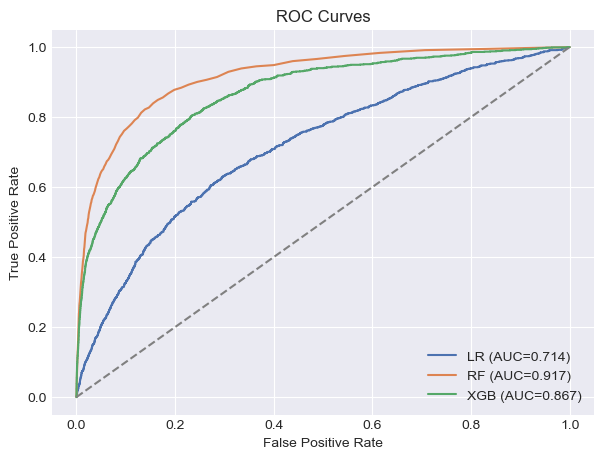

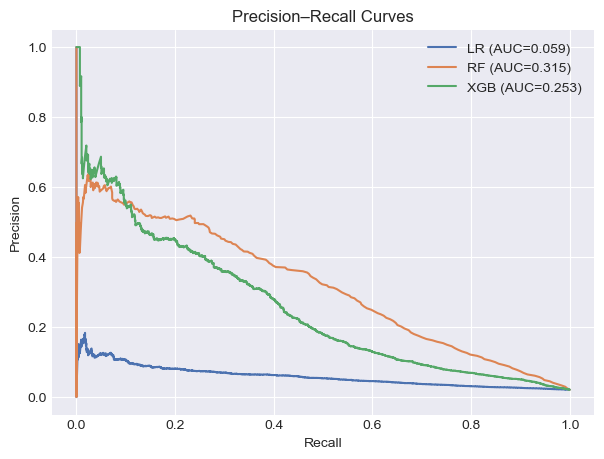

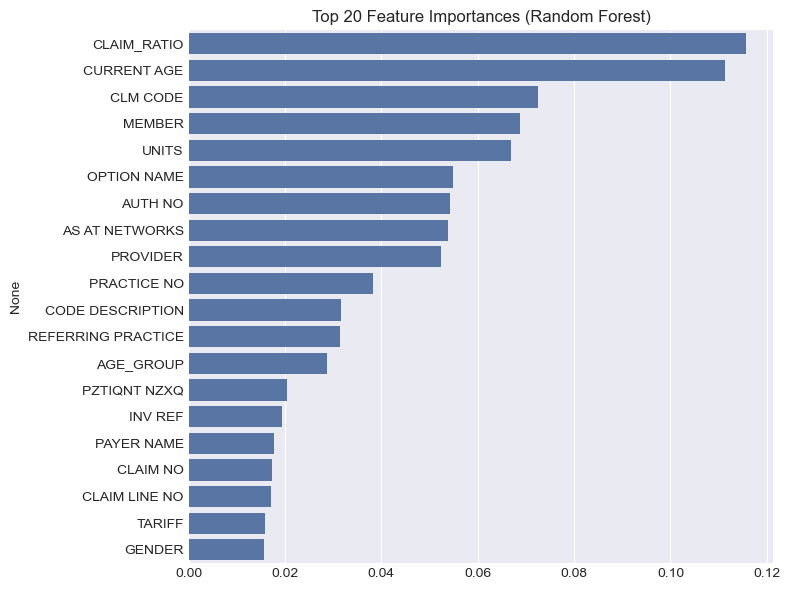

In [74]:
plt.figure(figsize=(7,5))
for name, proba in results.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
plt.plot([0,1],[0,1],'--', color='gray')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
for name, proba in results.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    plt.plot(rec, prec, label=f"{name} (AUC={auc(rec,prec):.3f})")
plt.title("Precision–Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

# Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:20]
plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Top 20 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

Save Outputs

In [76]:
pred_df = pd.DataFrame({
    'Actual': y_test,
    'Prob_LR': y_proba_lr,
    'Prob_RF': y_proba_rf,
    'Prob_XGB': y_proba_xgb,
    'Pred_RF_Opt': y_pred_rf_opt
})
pred_df.to_csv("enhanced_predictions.csv", index=False)
print("✅ Saved enhanced_predictions.csv")

✅ Saved enhanced_predictions.csv


# More Plots

 ROC Curves for all models

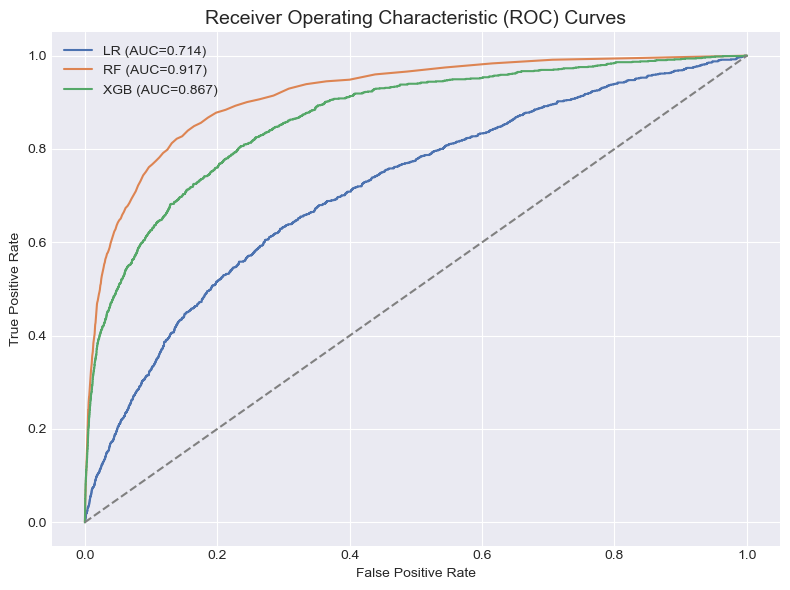

In [79]:
plt.figure(figsize=(8,6))
for name, proba in results.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0,1],[0,1],'--',color='gray')
plt.title("Receiver Operating Characteristic (ROC) Curves", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

Precision–Recall Curves

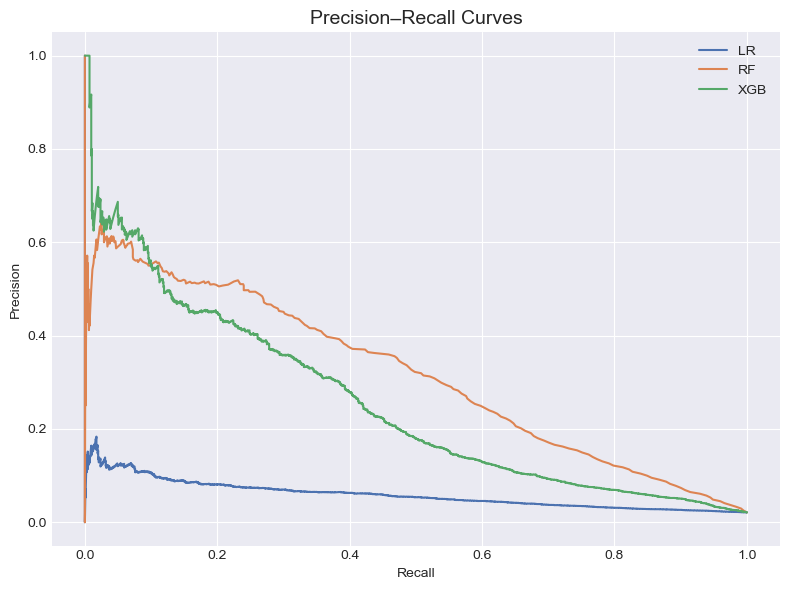

In [81]:
plt.figure(figsize=(8,6))
for name, proba in results.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    plt.plot(rec, prec, label=f"{name}")
plt.title("Precision–Recall Curves", fontsize=14)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

Confusion Matrices (Side-by-Side)

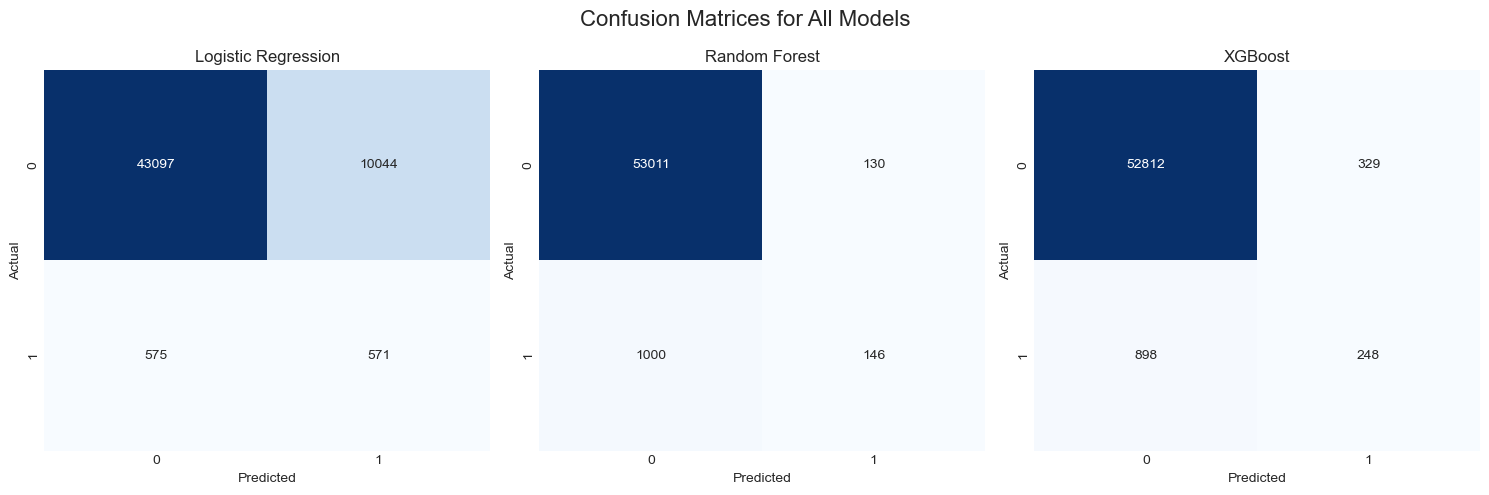

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
models = {
    "Logistic Regression": (y_test, y_pred_lr),
    "Random Forest": (y_test, y_pred_rf),
    "XGBoost": (y_test, y_pred_xgb)
}
for ax, (name, (yt, yp)) in zip(axes, models.items()):
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices for All Models", fontsize=16)
plt.tight_layout()
plt.show()

Feature Importances (Random Forest + XGBoost)

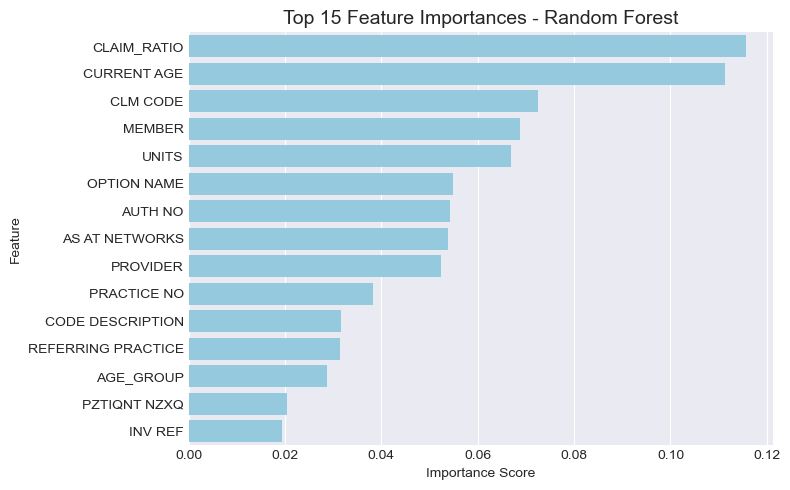

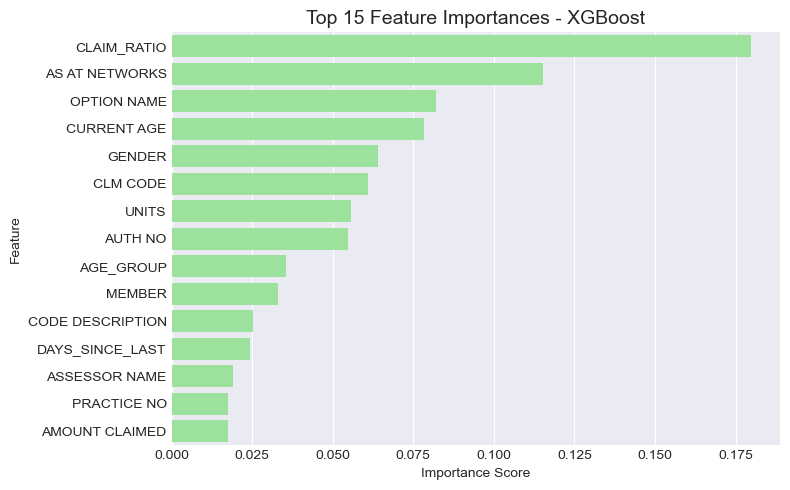

In [85]:
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:15]
plt.figure(figsize=(8,5))
sns.barplot(x=rf_importance.values, y=rf_importance.index, color="skyblue")
plt.title("Top 15 Feature Importances - Random Forest", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


xgb_importance = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)[:15]
plt.figure(figsize=(8,5))
sns.barplot(x=xgb_importance.values, y=xgb_importance.index, color="lightgreen")
plt.title("Top 15 Feature Importances - XGBoost", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Class Distribution Before vs After SMOTE

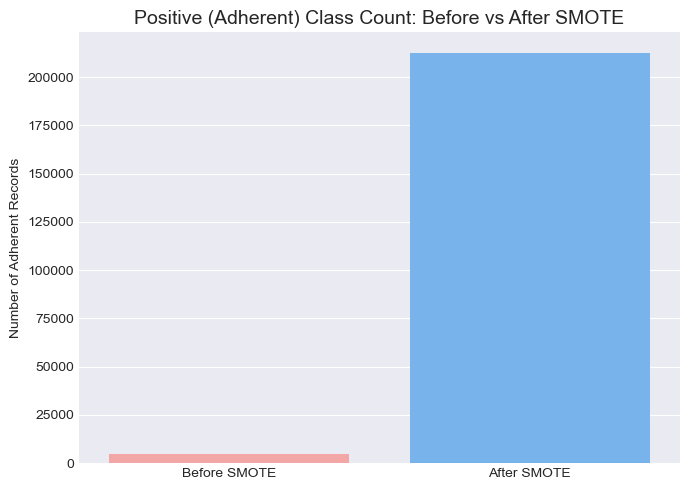

In [87]:
plt.figure(figsize=(7,5))
sns.barplot(x=["Before SMOTE", "After SMOTE"],
            y=[np.bincount(y_train)[1], np.bincount(y_train_bal)[1]],
            palette=["#ff9999","#66b3ff"])
plt.title("Positive (Adherent) Class Count: Before vs After SMOTE", fontsize=14)
plt.ylabel("Number of Adherent Records")
plt.tight_layout()
plt.show()

Metrics Comparison Bar Chart (F1, Recall, Precision, AUC)

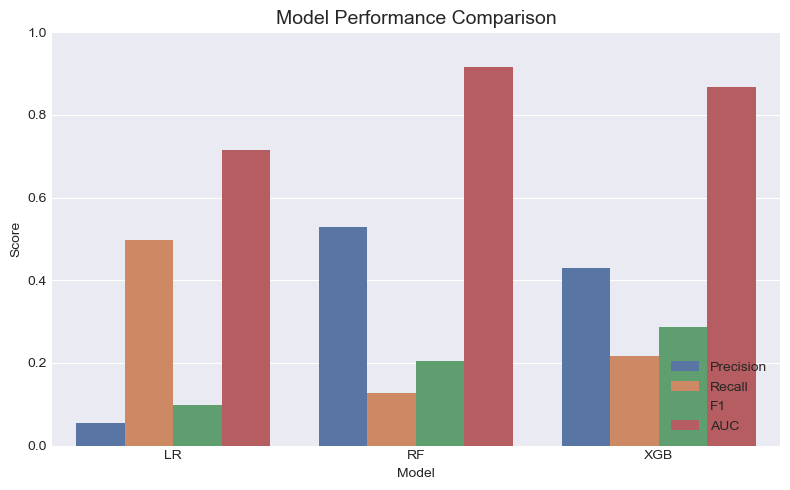

In [89]:
metrics_df = pd.DataFrame(columns=["Model", "Precision", "Recall", "F1", "AUC"])
for name, pred in zip(["LR","RF","XGB"], [y_pred_lr, y_pred_rf, y_pred_xgb]):
    report = classification_report(y_test, pred, output_dict=True)
    auc_val = roc_auc_score(y_test, results[name])
    metrics_df = pd.concat([metrics_df, pd.DataFrame({
        "Model": [name],
        "Precision": [report["1"]["precision"]],
        "Recall": [report["1"]["recall"]],
        "F1": [report["1"]["f1-score"]],
        "AUC": [auc_val]
    })])

plt.figure(figsize=(8,5))
metrics_df_melted = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(x="Model", y="Score", hue="Metric", data=metrics_df_melted)
plt.title("Model Performance Comparison", fontsize=14)
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Final Summary

In [91]:
print("\n-Finished running pipeline")
print("Files saved to current working directory:")
for f in ["scaler.joblib", "label_encoders.joblib", "logistic_model.joblib", "random_forest_model.joblib",
          "classification_test_predictions.csv", "lstm_adherence_model.h5", "lstm_patient_risk_predictions.csv"]:
    if os.path.exists(f):
        print(" -", f)

for model_name, proba in results.items():
    auc_val = roc_auc_score(y_test, proba)
    print(f"{model_name} ROC-AUC: {auc_val:.3f}")
print(f"Random Forest (optimized threshold) Recall={best_recall:.3f}, Precision={best_prec:.3f}")


-Finished running pipeline
Files saved to current working directory:
 - scaler.joblib
 - label_encoders.joblib
 - logistic_model.joblib
 - random_forest_model.joblib
 - classification_test_predictions.csv
 - lstm_patient_risk_predictions.csv
LR ROC-AUC: 0.714
RF ROC-AUC: 0.917
XGB ROC-AUC: 0.867
Random Forest (optimized threshold) Recall=0.468, Precision=0.356
